# ExoLinker: Full Planetary Profile Generation
This notebook demonstrates how to couple an `exowrap` atmosphere model with a `fuzzycore` interior model to generate a continuous, mathematically rigorous planetary profile.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import our newly built exolinker package!
from exoweave import ExoCoupler, save_converged_model

# Set matplotlib style for nice scientific plots
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 12

In [6]:
target_params = {
    "mass": 1.0,               # Jupiter masses
    "T_irr": 1100.0,           # Irradiation temperature (K)
    "T_int": 400.0,            # Intrinsic temperature (K)
    "Met": 0.0,                # Metallicity (log10 Z/Z_solar)
    "core_mass_earth": 15.0,   # Solid core mass in Earth masses
    "iron_fraction": 0.33,     # Earth-like core composition
    "f_sed": 1.0,              # Cloud sedimentation
    "kzz": 8.0,                # Eddy diffusion (log10)
    "debug": False
}

# 2. Define the numerical configuration for the solver
config = {
    "resolution": 50,                  
    "max_iterations": 15,              
    "mass_convergence_threshold": 0.01,
    "p_bottom_bar": 1000.0,
    "output_dir": "./exoweave_outputs"
}

In [7]:
# 3. Initialize the Orchestrator
coupler = ExoCoupler(target_params=target_params, config=config)

# 4. Fire the main solver loop! (This will take a few minutes)
print("🚀 Launching ExoLinker...")
results = coupler.run()

if results['status'] == 'converged':
    print(f"\n✅ Success! Converged in {results['iterations']} iterations.")
    print(f"Final T_int: {results['final_params']['T_int']:.1f} K")
    print(f"Final g_1bar: {results['final_params']['g_1bar']:.2f} m/s²")
else:
    print("\n❌ Solver failed to converge. Check the history for details.")


if results['status'] == 'failed':
    # Now this will successfully grab the DataFrame!
    raw_atm = results['atmosphere_raw']
    print("\n--- Failed Run Diagnostics ---")
    
    # Expose the ExoremOut properties
    from exowrap.output import ExoremOut
    exo = ExoremOut(raw_atm)
    
    print(f"Atmosphere T_int used: {exo.t_int:.1f} K")
    print(f"Atmosphere Gravity used: {exo.gravity[-1]:.2f} m/s²")
    
    # Find the boundary conditions it tried to pass to fuzzycore
    p_levels_bar = exo.pressure_levels / 1e5
    t_levels = exo.temperature_levels
    
    # Let's see what the temperature is at 100 bar!
    idx_link = np.argmin(np.abs(p_levels_bar - config['p_link_target_bar']))
    
    print(f"Deepest Exorem Boundary: P = {p_levels_bar[idx_link]:.2f} bar, T = {t_levels[idx_link]:.1f} K")


INFO: 💡 Smart Initialization: Guessed g = 24.78 m/s² for M = 1.0 M_Jup
INFO: 🌌 Grid Setup: Pushing atmospheric boundary down to 1000.0 bars.
INFO: 
INFO: 🔄 ITERATION 1/15 | Target Mass: 1.0 M_Jup | g: 24.78 m/s²
INFO: ========================================
INFO: Starting ExoREM Simulation...
INFO: Generated namelist at /private/var/folders/ld/pl_0zzs158sb8h6_y3mrd0lm0000gp/T/tmp2l3cizby/input.nml
INFO: Running Fortran backend from /Users/cwilkinson/.exowrap/exorem_source/dist/dist/exorem/bin...


🚀 Launching ExoLinker...


INFO: Parsing results from /private/var/folders/ld/pl_0zzs158sb8h6_y3mrd0lm0000gp/T/tmp2l3cizby/outputs/exowrap_run.h5...
INFO: Simulation complete.
INFO: 🔗 Dynamic Junction: Anchoring to thickest convective block at P = 44.67 bar
INFO: 🧪 Chemical Sync: Derived Z_base = 0.0000, Y_ratio = 0.1429 (from X=1.4796, Y=0.2467)


--- Loading Raw EOS Tables (From Disk) ---
  > Loading Hydrogen...
  > Loading Helium...
  > Loading Water...
  > Loading Rock...
  > Loading Iron...
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


INFO: Calculated T_int: 388.96 K (Avg Deep Flux = 1.298e+03 W/m²)
INFO: 📊 Breakdown: Interior Mass = 1.4979 M_Jup
INFO: 📊 Breakdown: Atm Mass = 0.000009 M_Jup (0.001% of total)
INFO: 📊 Results: Total Calc Mass = 1.498 M_Jup (Error: 49.79%)
INFO: 📊 Results: True Measured T_int = 389.0 K (Input dial: 400.0 K)
INFO: Stitching profiles at P_link = 44.67 bar
INFO: 📈 Secant Prep: Nudging gravity to establish mass gradient.
INFO: 
INFO: 🔄 ITERATION 2/15 | Target Mass: 1.0 M_Jup | g: 26.02 m/s²
INFO: ========================================
INFO: 🔥 Warm Start: Injecting P-T profile from iteration 1
INFO: Starting ExoREM Simulation...
INFO: Generated namelist at /private/var/folders/ld/pl_0zzs158sb8h6_y3mrd0lm0000gp/T/tmpm8x__qee/input.nml
INFO: Running Fortran backend from /Users/cwilkinson/.exowrap/exorem_source/dist/dist/exorem/bin...
INFO: Parsing results from /private/var/folders/ld/pl_0zzs158sb8h6_y3mrd0lm0000gp/T/tmpm8x__qee/outputs/exowrap_run.h5...
INFO: Simulation complete.
INFO: 🔗 Dy

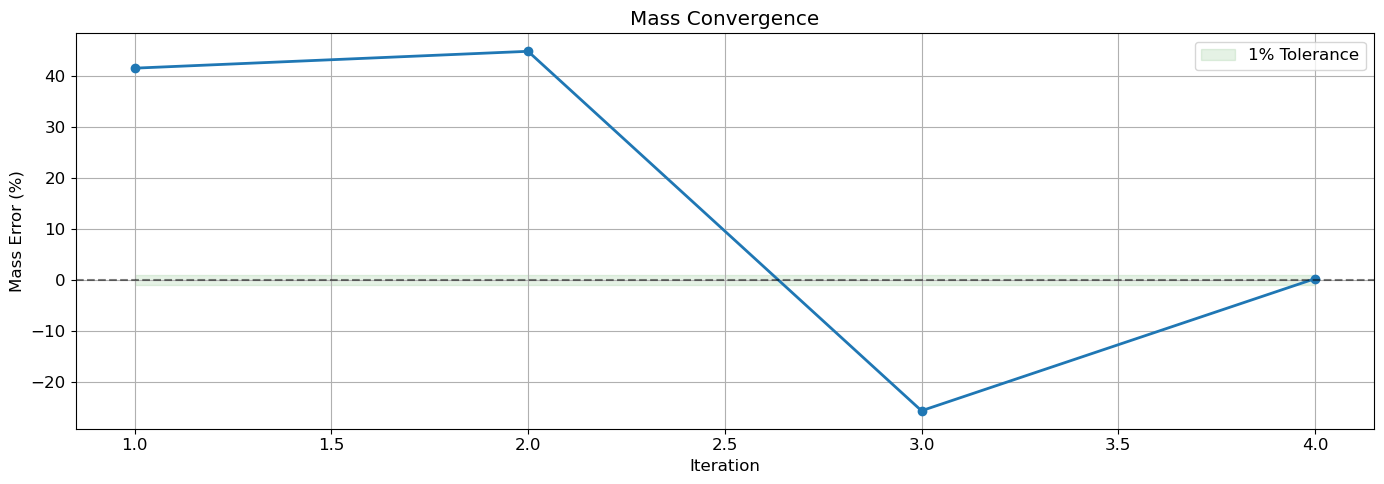

In [4]:
# 5. Visualize the Secant Method at work
history = coupler.history

fig, (ax1) = plt.subplots(1, 1, figsize=(14, 5))

# Gravity Error Plot
ax1.plot(history['iteration'], np.array(history['mass_error']) * 100, marker='o', color='tab:blue', lw=2)
ax1.axhline(0, color='black', linestyle='--', alpha=0.5)
ax1.fill_between(history['iteration'], -1, 1, color='green', alpha=0.1, label="1% Tolerance")
ax1.set_title("Mass Convergence")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Mass Error (%)")
ax1.legend()


plt.tight_layout()
plt.show()

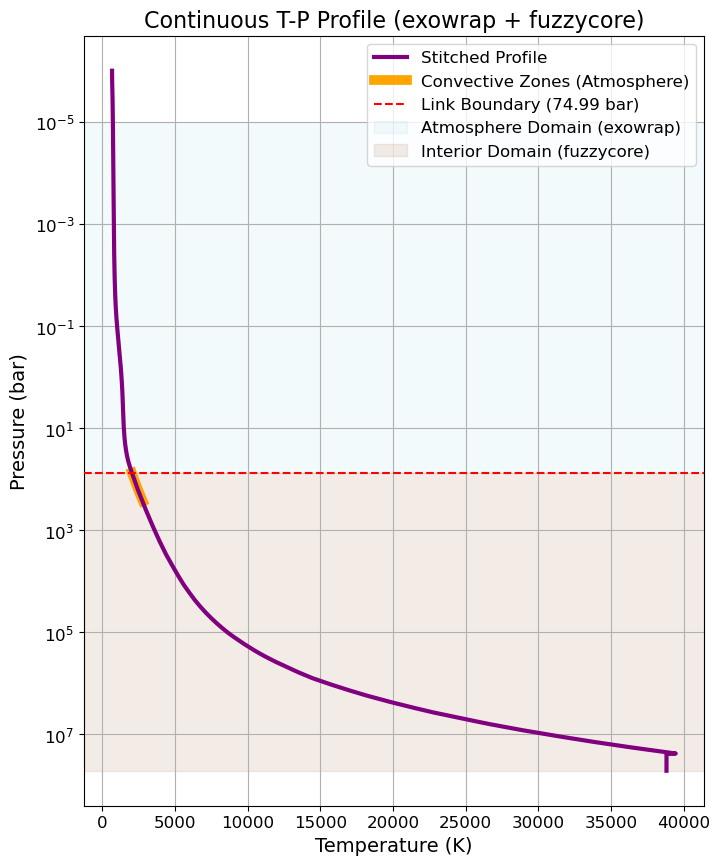

In [7]:
# 6. Visualize the continuous planetary profile
if results['status'] == 'converged':
    df = results['stitched_profile']
    p_link = results['final_params']['p_link_bar']
    
    fig, ax = plt.subplots(figsize=(8, 10))
    
    # 1. Plot the full stitched profile
    ax.plot(df['Temperature_K'], df['Pressure_bar'], color='purple', lw=3, zorder=3, label='Stitched Profile')
    
    # 2. Extract and overlay the convective zones from the atmosphere!
    atm_raw = results['atmosphere_raw']
    p_atm_bar = atm_raw['/outputs/levels/pressure'].iloc[0] / 1e5
    t_atm = atm_raw['/outputs/levels/temperature'].iloc[0]
    is_conv = atm_raw['/outputs/levels/is_convective'].iloc[0].astype(bool)
    
    # Replace all non-convective temperatures with NaN
    t_conv = np.where(is_conv, t_atm, np.nan)
    
    # Plot the bold overlay (Matplotlib automatically skips the NaNs!)
    ax.plot(t_conv, p_atm_bar, color='orange', lw=7, zorder=2, label='Convective Zones (Atmosphere)')
    
    # 3. Draw a line showing exactly where the two models linked
    ax.axhline(p_link, color='red', linestyle='--', zorder=4, label=f'Link Boundary ({p_link:.2f} bar)')
    
    # 4. Format the axes for atmospheric science standards (log pressure, inverted)
    ax.set_yscale('log')
    ax.invert_yaxis()
    ax.set_xlabel("Temperature (K)", fontsize=14)
    ax.set_ylabel("Pressure (bar)", fontsize=14)
    ax.set_title("Continuous T-P Profile (exowrap + fuzzycore)", fontsize=16)
    
    # 5. Fill background colors to show domains
    ax.axhspan(1e-5, p_link, color='skyblue', alpha=0.1, label='Atmosphere Domain (exowrap)')
    ax.axhspan(p_link, df['Pressure_bar'].max(), color='saddlebrown', alpha=0.1, label='Interior Domain (fuzzycore)')
    
    ax.legend(loc='upper right')
    plt.show()

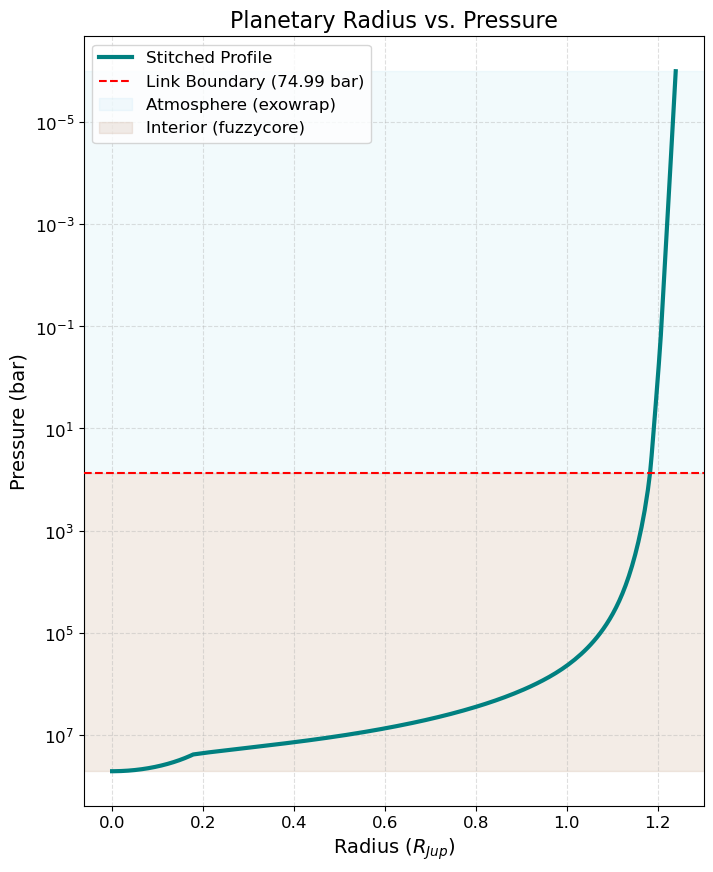

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure we have a converged result to plot
if results['status'] == 'converged':
    df = results['stitched_profile']
    p_link = results['final_params']['p_link_bar']
    
    # Handle column names dynamically (in case your master profile uses meters instead of Jupiter Radii)
    if 'Radius_Rjup' in df.columns:
        r_col = 'Radius_Rjup'
        x_label = "Radius ($R_{Jup}$)"
    elif 'Radius_m' in df.columns:
        # Convert meters to Jupiter radii on the fly (1 R_Jup = 71,492,000 m)
        df['Radius_Rjup_tmp'] = df['Radius_m'] / 71492000.0
        r_col = 'Radius_Rjup_tmp'
        x_label = "Radius ($R_{Jup}$)"
    else:
        # Fallback if standard names aren't found
        r_col = [col for col in df.columns if 'rad' in col.lower()][0]
        x_label = "Radius"
    
    fig, ax = plt.subplots(figsize=(8, 10))
    
    # 1. Plot the continuous Radius vs. Pressure curve
    ax.plot(df[r_col], df['Pressure_bar'], color='teal', lw=3, zorder=3, label='Stitched Profile')
    
    # 2. Draw a line showing exactly where the two models linked
    ax.axhline(p_link, color='red', linestyle='--', zorder=4, label=f'Link Boundary ({p_link:.2f} bar)')
    
    # 3. Format the axes (Log pressure, inverted so the deep core is at the bottom)
    ax.set_yscale('log')
    ax.invert_yaxis()
    ax.set_xlabel(x_label, fontsize=14)
    ax.set_ylabel("Pressure (bar)", fontsize=14)
    ax.set_title("Planetary Radius vs. Pressure", fontsize=16)
    
    # 4. Fill background colors to show physical domains
    ax.axhspan(df['Pressure_bar'].min(), p_link, color='skyblue', alpha=0.1, label='Atmosphere (exowrap)')
    ax.axhspan(p_link, df['Pressure_bar'].max(), color='saddlebrown', alpha=0.1, label='Interior (fuzzycore)')
    
    # Add a grid for easier reading of specific depths
    plt.grid(True, which="both", ls="--", alpha=0.4)
    ax.legend(loc='upper left')
    
    plt.show()
else:
    print("The model did not converge. Please check the logs!")